In [22]:
import pandas as pd
# Infer datatype for column 14
df = pd.read_csv("data/clean/merged_df.csv", low_memory=False)
df.columns

Index(['hotel', 'lead_time', 'arrival_year', 'arrival_month',
       'stays_in_weekend_nights', 'stays_in_week_nights',
       'market_segment_type', 'country', 'avg_price_per_room', 'email',
       'is_canceled', 'arrival_day', 'arrival_date', 'Booking_ID'],
      dtype='object')

1. Calculate Cancelation rates for each month

In [2]:
cancel_rate_by_month = (
    df.groupby('arrival_month')['is_canceled']
    .mean()
    .mul(100)
    .reset_index(name='cancel_rate (%)')
    .sort_values('arrival_month')
)

print(cancel_rate_by_month)

    arrival_month  cancel_rate (%)
0               1        17.811159
1               2        31.581769
2               3        30.311891
3               4        37.432631
4               5        35.450718
5               6        39.870512
6               7        39.657187
7               8        38.472385
8               9        37.396653
9              10        37.179098
10             11        30.662983
11             12        28.293031


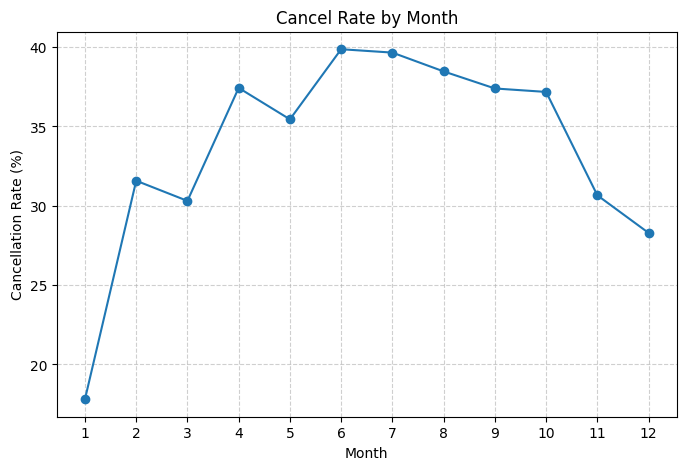

In [11]:
import matplotlib.pyplot as plt

# Line plot of cancellation rate by month
plt.figure(figsize=(8, 5))
plt.plot(
    cancel_rate_by_month['arrival_month'],
    cancel_rate_by_month['cancel_rate (%)'],
    marker='o'
)

plt.title("Cancel Rate by Month")
plt.xlabel("Month")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(range(1, 13))
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

2. Compute Average price and average number of nights for each month.

In [12]:
df['nights_stayed'] = df['stays_in_week_nights'] + df['stays_in_weekend_nights']
df.groupby("arrival_month")[["avg_price_per_room", 'nights_stayed']].mean()

,avg_price_per_room,nights_stayed
arrival_month,,
1,67.870616,2.738197
2,73.340136,2.877033
3,83.276551,3.210805
4,93.302379,3.117834
5,102.000425,3.133358
6,108.858464,3.157151
7,114.074734,3.758181
8,122.761549,3.645985
9,108.360909,3.288313


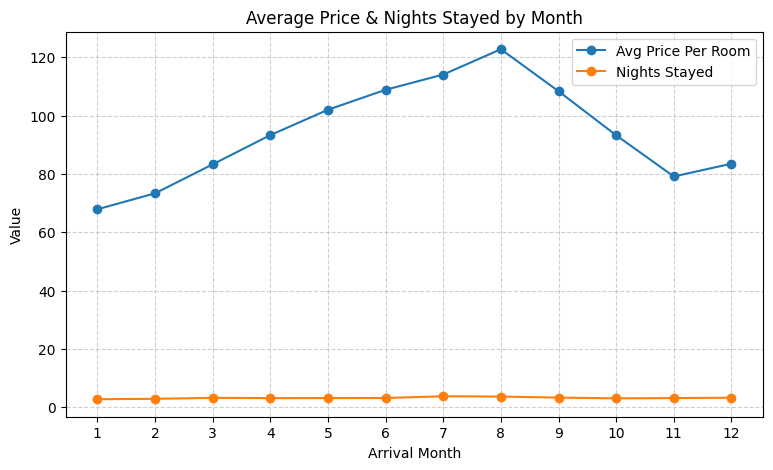

In [13]:
import matplotlib.pyplot as plt

# Calculate monthly averages
monthly_avg = (
    df.groupby("arrival_month")[["avg_price_per_room", "nights_stayed"]]
    .mean()
    .reset_index()
)

# Line plot
plt.figure(figsize=(9, 5))

plt.plot(
    monthly_avg['arrival_month'],
    monthly_avg['avg_price_per_room'],
    marker='o',
    label='Avg Price Per Room'
)

plt.plot(
    monthly_avg['arrival_month'],
    monthly_avg['nights_stayed'],
    marker='o',
    label='Nights Stayed'
)

plt.title("Average Price & Nights Stayed by Month")
plt.xlabel("Arrival Month")
plt.ylabel("Value")
plt.xticks(range(1, 13))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

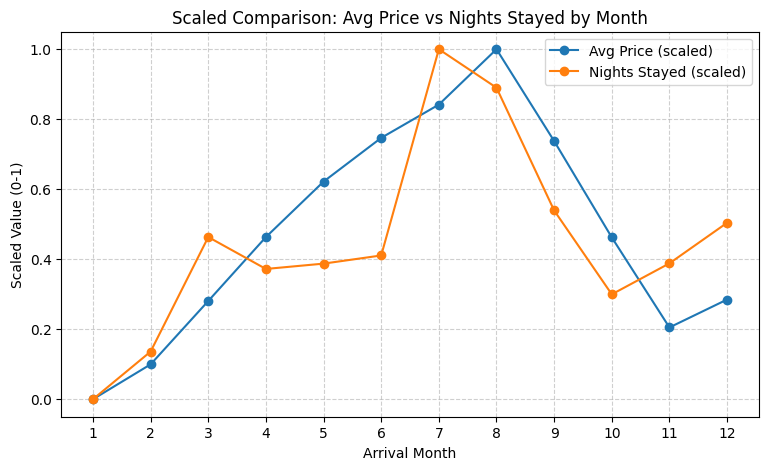

In [14]:
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Prepare data
monthly_avg = (
    df.groupby("arrival_month")[["avg_price_per_room", "nights_stayed"]]
    .mean()
    .reset_index()
)

scaler = MinMaxScaler()
scaled = scaler.fit_transform(monthly_avg[["avg_price_per_room", "nights_stayed"]])

monthly_avg['price_scaled'] = scaled[:, 0]
monthly_avg['nights_scaled'] = scaled[:, 1]

# Plot
plt.figure(figsize=(9, 5))
plt.plot(monthly_avg['arrival_month'], monthly_avg['price_scaled'], marker='o', label='Avg Price (scaled)')
plt.plot(monthly_avg['arrival_month'], monthly_avg['nights_scaled'], marker='o', label='Nights Stayed (scaled)')

plt.title("Scaled Comparison: Avg Price vs Nights Stayed by Month")
plt.xlabel("Arrival Month")
plt.ylabel("Scaled Value (0-1)")
plt.xticks(range(1, 13))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

3. Count monthly booking by market segment.

   - TA: Travel Agents
   - TO: Tour Operators

In [4]:
df['market_segment_type'].unique()

monthly_bookings = (
    df.groupby(["arrival_month", "market_segment_type"])
      .size()                      # counts the number of rows (bookings)
      .reset_index(name="bookings")  # rename the count column
)

monthly_bookings.to_csv("monthly_market_segment.csv")

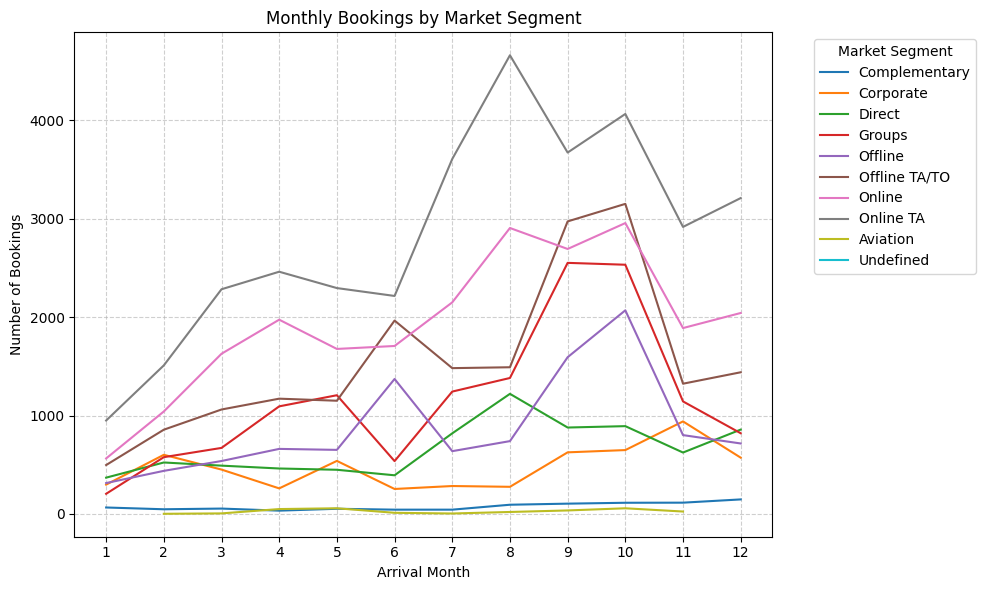

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

# Create the line plot
plt.figure(figsize=(10, 6))
for segment in monthly_bookings['market_segment_type'].unique():
    data = monthly_bookings[monthly_bookings['market_segment_type'] == segment]
    plt.plot(data['arrival_month'], data['bookings'], label=segment)

# Style the chart
plt.title("Monthly Bookings by Market Segment")
plt.xlabel("Month")
plt.ylabel("Number of Bookings")
plt.xticks(range(1, 13))
plt.legend(title="Market Segment", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

4. Identify the most popular month of the year for bookings based on revenue.

In [6]:
# If not already extracted
df["month"] = pd.to_datetime(df["arrival_date"]).dt.month

# Compute total revenue per month
monthly_revenue = df.groupby("month")["avg_price_per_room"].sum().reset_index()

# Identify the top month
most_popular_month = monthly_revenue.loc[monthly_revenue["avg_price_per_room"].idxmax()]
print(f"Most popular month: {most_popular_month['month']} with total revenue: {most_popular_month['avg_price_per_room']:.2f}")

Most popular month: 9.0 with total revenue: 1638308.59


<Axes: title={'center': 'Monthly Revenue by Bookings'}, xlabel='month'>

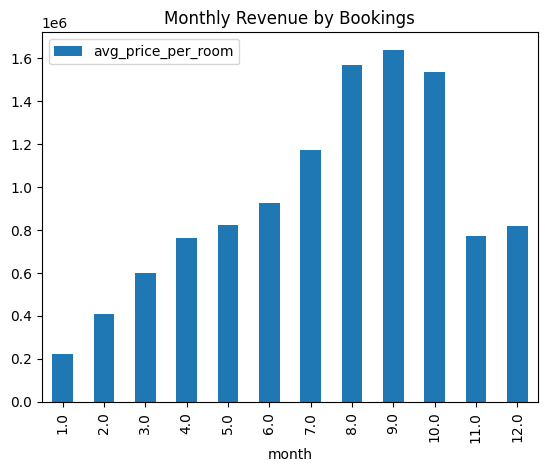

In [7]:
monthly_revenue.plot(x="month", y="avg_price_per_room", kind="bar", title="Monthly Revenue by Bookings")